# EDA FD004 - conditions y patrones de degradacion

Objetivo: analizar FD004, el subset mas complejo de C-MAPSS, que combina seis condiciones operativas y dos modos de falla declarados.

La estrategia es secuencial: primero identificar y controlar las conditions; luego buscar patrones residuales de degradacion en sensores normalizados por condition. Sin etiquetas reales de fault mode por motor, cualquier cluster debe leerse como hipotesis exploratoria.


## 1. Setup


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import FEATURE_COLUMNS, SENSOR_COLUMNS, SETTING_COLUMNS, add_train_rul, last_cycle_rows, load_cmapss_subset
from src.eda import correlation_with_target, dataset_overview

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid")

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42


## 2. Carga de FD004

FD004 combina la complejidad de FD002 y FD003: seis condiciones operativas y dos modos de falla. Por eso no conviene buscar patrones de falla sin controlar primero el regimen operativo.


In [2]:
data = load_cmapss_subset("FD004", data_dir=PROJECT_ROOT / "CMAPSSData")
train = add_train_rul(data.train)
test = data.test.copy()
test_last = last_cycle_rows(test).merge(data.rul, on="unit", how="left")

overview = dataset_overview(data.train, data.test, data.rul)
overview


,dataset,rows,columns,units,missing_values,duplicated_rows
0,train,61249,26,249,0,0
1,test,41214,26,248,0,0
2,rul,248,2,248,0,0


In [3]:
setting_summary = train[SETTING_COLUMNS].agg(["mean", "std", "min", "max"]).T
setting_summary


,mean,std,min,max
setting_1,23.9998,14.7807,0.0000,42.0080
setting_2,0.5713,0.3107,0.0000,0.8420
setting_3,94.0316,14.2520,60.0000,100.0000


## 3. Identificacion de conditions

Se repite la logica de FD002: usar los tres settings para recuperar las seis condiciones operativas. Esto define el eje de preprocesamiento antes de estudiar degradacion.


In [4]:
settings_scaler = StandardScaler()
settings_X = settings_scaler.fit_transform(train[SETTING_COLUMNS])

settings_sample = train[SETTING_COLUMNS].sample(
    min(12000, len(train)),
    random_state=RANDOM_STATE,
)
settings_sample_X = settings_scaler.transform(settings_sample)

k_rows = []
for k in range(2, 10):
    labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit_predict(settings_sample_X)
    k_rows.append({"k": k, "silhouette_sample": silhouette_score(settings_sample_X, labels)})

condition_k_summary = pd.DataFrame(k_rows)
condition_k_summary


,k,silhouette_sample
0,2,0.6175
1,3,0.8022
2,4,0.8499
3,5,0.9302
4,6,0.9971
5,7,0.9360
6,8,0.8996
7,9,0.8593


In [5]:
condition_model = KMeans(n_clusters=6, random_state=RANDOM_STATE, n_init=50)
train_raw_condition = condition_model.fit_predict(settings_X)

centers = pd.DataFrame(
    settings_scaler.inverse_transform(condition_model.cluster_centers_),
    columns=SETTING_COLUMNS,
)
centers["raw_condition"] = range(len(centers))
centers = centers.sort_values(SETTING_COLUMNS).reset_index(drop=True)
centers["condition_id"] = range(1, len(centers) + 1)
condition_mapping = dict(zip(centers["raw_condition"], centers["condition_id"]))

train_cond = train.copy()
train_cond["condition_id"] = pd.Series(train_raw_condition).map(condition_mapping).to_numpy()

test_raw_condition = condition_model.predict(settings_scaler.transform(test[SETTING_COLUMNS]))
test_cond = test.copy()
test_cond["condition_id"] = pd.Series(test_raw_condition).map(condition_mapping).to_numpy()

test_last_cond = last_cycle_rows(test_cond).merge(data.rul, on="unit", how="left")

centers[["condition_id"] + SETTING_COLUMNS]


,condition_id,setting_1,setting_2,setting_3
0,1,0.0015,0.0005,100.0000
1,2,10.0030,0.2505,100.0000
2,3,20.0030,0.7005,100.0000
3,4,25.0031,0.6205,60.0000
4,5,35.0030,0.8405,100.0000
5,6,42.0030,0.8405,100.0000


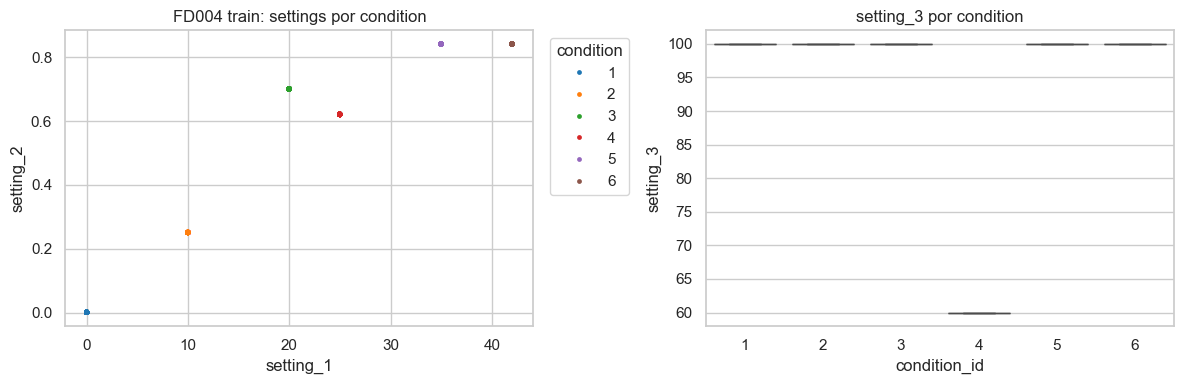

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(
    data=train_cond.sample(min(12000, len(train_cond)), random_state=RANDOM_STATE),
    x="setting_1",
    y="setting_2",
    hue="condition_id",
    palette="tab10",
    s=12,
    linewidth=0,
    ax=axes[0],
)
axes[0].set_title("FD004 train: settings por condition")
axes[0].legend(title="condition", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.boxplot(data=train_cond, x="condition_id", y="setting_3", ax=axes[1], showfliers=False)
axes[1].set_title("setting_3 por condition")
axes[1].set_xlabel("condition_id")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd004_conditions_settings_clusters.png", dpi=150)
plt.show()


## 4. Balance train/test por condition

Si train y test tienen proportions distintas de conditions, el modelo puede enfrentar shift operativo. Tambien se revisa si cada motor recorre todas las conditions.


In [7]:
def condition_distribution(df: pd.DataFrame, split: str) -> pd.DataFrame:
    counts = df["condition_id"].value_counts().sort_index()
    result = counts.rename("rows").reset_index().rename(columns={"index": "condition_id"})
    result["condition_id"] = result["condition_id"].astype(int)
    result["row_pct"] = result["rows"] / result["rows"].sum() * 100
    result["units"] = df.groupby("condition_id")["unit"].nunique().reindex(result["condition_id"]).to_numpy()
    result["split"] = split
    return result

condition_dist = pd.concat(
    [
        condition_distribution(train_cond, "train_rows"),
        condition_distribution(test_cond, "test_rows"),
        condition_distribution(test_last_cond, "test_last_cycle"),
    ],
    ignore_index=True,
)
condition_dist


,condition_id,rows,row_pct,units,split
0,1,9238,15.0827,249,train_rows
1,2,9224,15.0598,249,train_rows
2,3,9091,14.8427,249,train_rows
3,4,9139,14.9211,249,train_rows
4,5,9162,14.9586,249,train_rows
5,6,15395,25.1351,249,train_rows
6,1,6054,14.6892,248,test_rows
7,2,6185,15.0070,248,test_rows
8,3,6254,15.1745,248,test_rows
9,4,6107,14.8178,248,test_rows


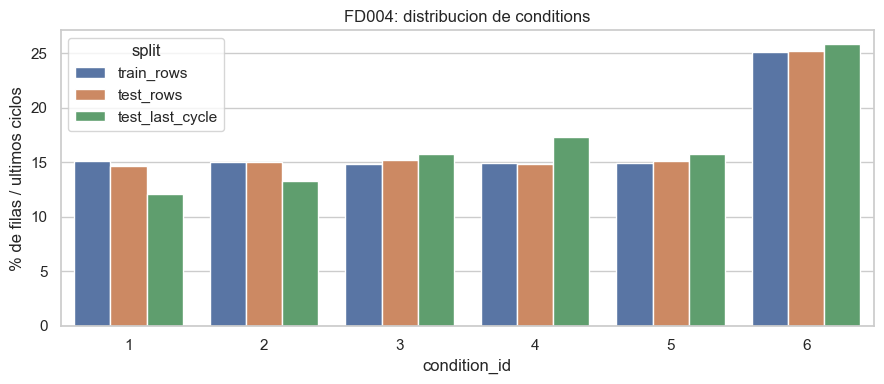

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=condition_dist, x="condition_id", y="row_pct", hue="split", ax=ax)
ax.set_title("FD004: distribucion de conditions")
ax.set_xlabel("condition_id")
ax.set_ylabel("% de filas / ultimos ciclos")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd004_condition_distribution.png", dpi=150)
plt.show()


In [9]:
unit_condition_counts = train_cond.groupby("unit")["condition_id"].nunique().describe()
unit_condition_counts


count   249.0000
mean      6.0000
std       0.0000
min       6.0000
25%       6.0000
50%       6.0000
75%       6.0000
max       6.0000
Name: condition_id, dtype: float64

## 5. Senal RUL controlando por condition

Primero se verifica si ocurre lo mismo que en FD002: correlaciones globales bajas, pero correlaciones fuertes dentro de cada condition o luego de normalizar por condition.


In [10]:
global_corr = correlation_with_target(train_cond, target="RUL", columns=SENSOR_COLUMNS)

def corr_by_condition(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for condition_id, group in df.groupby("condition_id"):
        corr = correlation_with_target(group, target="RUL", columns=SENSOR_COLUMNS)
        for sensor, row in corr.iterrows():
            rows.append(
                {
                    "condition_id": condition_id,
                    "sensor": sensor,
                    "correlation": row["correlation"],
                    "abs_correlation": row["abs_correlation"],
                }
            )
    return pd.DataFrame(rows)

condition_corr = corr_by_condition(train_cond)
condition_corr_summary = (
    condition_corr.groupby("sensor")
    .agg(
        mean_abs_corr_by_condition=("abs_correlation", "mean"),
        max_abs_corr_by_condition=("abs_correlation", "max"),
    )
    .join(global_corr[["abs_correlation"]].rename(columns={"abs_correlation": "global_abs_corr"}))
)
condition_corr_summary["mean_abs_gain_vs_global"] = (
    condition_corr_summary["mean_abs_corr_by_condition"] - condition_corr_summary["global_abs_corr"]
)
condition_corr_summary.sort_values("mean_abs_gain_vs_global", ascending=False).head(12)


,mean_abs_corr_by_condition,max_abs_corr_by_condition,global_abs_corr,mean_abs_gain_vs_global
sensor,,,,
sensor_11,0.6868,0.7022,0.0566,0.6302
sensor_4,0.6514,0.6787,0.0459,0.6055
sensor_17,0.6048,0.6259,0.0329,0.5719
sensor_3,0.5826,0.6036,0.0329,0.5497
sensor_2,0.5345,0.5948,0.0044,0.5301
sensor_13,0.5093,0.6809,0.0015,0.5078
sensor_8,0.5087,0.6809,0.0021,0.5067
sensor_9,0.5228,0.5326,0.0247,0.4981
sensor_14,0.4488,0.4657,0.0781,0.3706


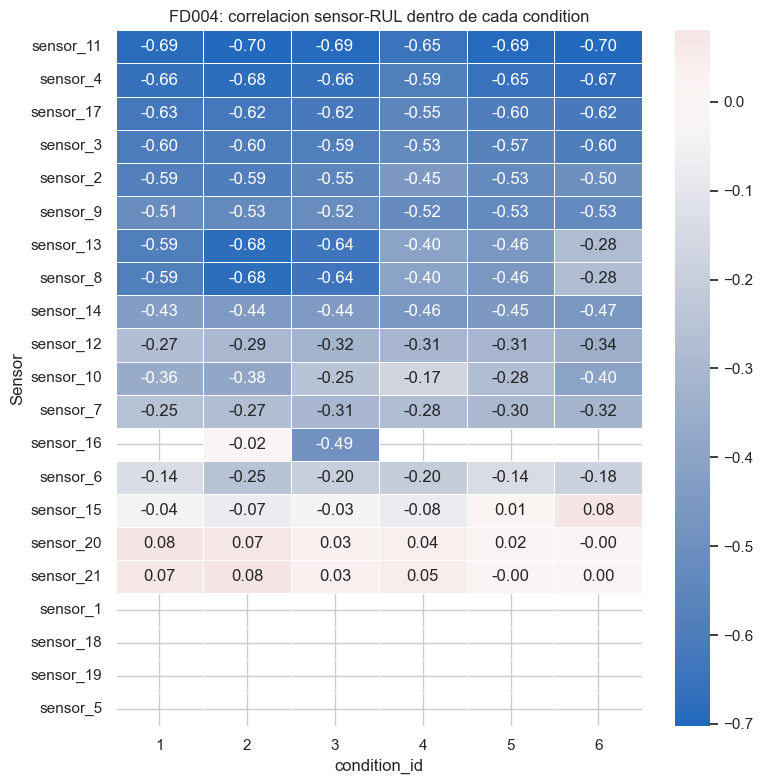

In [11]:
corr_heatmap = condition_corr.pivot(index="sensor", columns="condition_id", values="correlation")
ordered_sensors = corr_heatmap.abs().mean(axis=1).sort_values(ascending=False).index
corr_heatmap = corr_heatmap.loc[ordered_sensors]

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(corr_heatmap, cmap="vlag", center=0, annot=True, fmt=".2f", linewidths=0.4, ax=ax)
ax.set_title("FD004: correlacion sensor-RUL dentro de cada condition")
ax.set_xlabel("condition_id")
ax.set_ylabel("Sensor")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd004_sensor_rul_corr_by_condition_heatmap.png", dpi=150)
plt.show()


In [12]:
def add_condition_normalized_sensors(df: pd.DataFrame, reference_df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()
    for sensor in SENSOR_COLUMNS:
        stats = reference_df.groupby("condition_id")[sensor].agg(["mean", "std"])
        means = result["condition_id"].map(stats["mean"])
        stds = result["condition_id"].map(stats["std"]).replace(0, np.nan)
        result[f"{sensor}_cond_z"] = ((result[sensor] - means) / stds).fillna(0)
    return result

train_cond_norm = add_condition_normalized_sensors(train_cond, train_cond)
test_cond_norm = add_condition_normalized_sensors(test_cond, train_cond)
condition_norm_cols = [f"{sensor}_cond_z" for sensor in SENSOR_COLUMNS]

condition_norm_corr = correlation_with_target(train_cond_norm, target="RUL", columns=condition_norm_cols)
condition_norm_corr.index = [index.replace("_cond_z", "") for index in condition_norm_corr.index]

norm_corr_compare = global_corr[["abs_correlation"]].rename(columns={"abs_correlation": "raw_global_abs_corr"}).join(
    condition_norm_corr[["abs_correlation"]].rename(columns={"abs_correlation": "condition_z_abs_corr"})
)
norm_corr_compare["gain"] = norm_corr_compare["condition_z_abs_corr"] - norm_corr_compare["raw_global_abs_corr"]
norm_corr_compare.sort_values("gain", ascending=False).head(12)


,raw_global_abs_corr,condition_z_abs_corr,gain
sensor_11,0.0566,0.6881,0.6315
sensor_4,0.0459,0.6533,0.6074
sensor_17,0.0329,0.6065,0.5736
sensor_3,0.0329,0.5845,0.5516
sensor_2,0.0044,0.5315,0.5270
sensor_9,0.0247,0.5237,0.4990
sensor_13,0.0015,0.4869,0.4854
sensor_8,0.0021,0.4862,0.4842
sensor_14,0.0781,0.4504,0.3723
sensor_12,0.0016,0.3109,0.3093


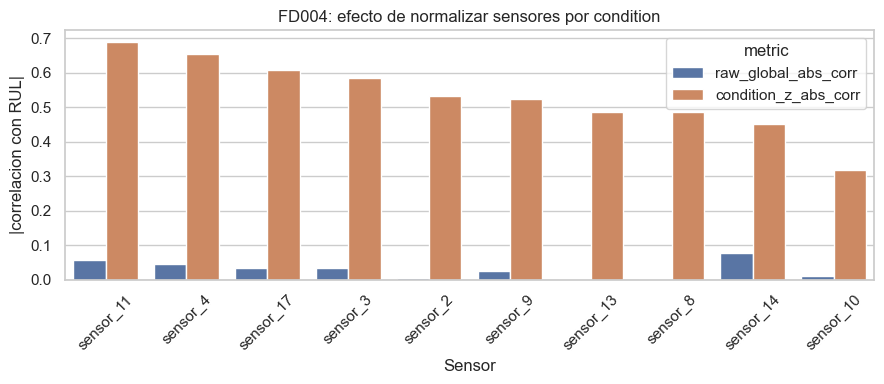

In [13]:
top_norm_compare = norm_corr_compare.sort_values("condition_z_abs_corr", ascending=False).head(10).reset_index().rename(columns={"index": "sensor"})
plot_norm = top_norm_compare.melt(
    id_vars="sensor",
    value_vars=["raw_global_abs_corr", "condition_z_abs_corr"],
    var_name="metric",
    value_name="abs_corr",
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=plot_norm, x="sensor", y="abs_corr", hue="metric", ax=ax)
ax.set_title("FD004: efecto de normalizar sensores por condition")
ax.set_xlabel("Sensor")
ax.set_ylabel("|correlacion con RUL|")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd004_condition_normalized_corr.png", dpi=150)
plt.show()


## 6. Clustering de patrones residuales

Luego de normalizar sensores por condition, se resume cada motor por su firma de degradacion residual. Esta es la version mas prudente del analisis de fault patterns en FD004.


In [14]:
def unit_degradation_signature(df: pd.DataFrame, sensor_cols: list[str]) -> pd.DataFrame:
    rows = []
    for unit, group in df.sort_values(["unit", "cycle"]).groupby("unit"):
        life_cycles = group["cycle"].max()
        first_window = group.head(min(5, len(group)))
        last_window = group.tail(min(5, len(group)))

        row = {"unit": unit, "life_cycles": life_cycles}
        for column in sensor_cols:
            start = first_window[column].mean()
            end = last_window[column].mean()
            row[f"{column}_start"] = start
            row[f"{column}_end"] = end
            row[f"{column}_delta"] = end - start
            row[f"{column}_slope"] = (end - start) / life_cycles

        rows.append(row)

    return pd.DataFrame(rows)

signature = unit_degradation_signature(train_cond_norm, condition_norm_cols)
signature.head()


,unit,life_cycles,sensor_1_cond_z_start,sensor_1_cond_z_end,sensor_1_cond_z_delta,sensor_1_cond_z_slope,sensor_2_cond_z_start,sensor_2_cond_z_end,sensor_2_cond_z_delta,sensor_2_cond_z_slope,sensor_3_cond_z_start,sensor_3_cond_z_end,sensor_3_cond_z_delta,sensor_3_cond_z_slope,sensor_4_cond_z_start,sensor_4_cond_z_end,sensor_4_cond_z_delta,sensor_4_cond_z_slope,sensor_5_cond_z_start,sensor_5_cond_z_end,sensor_5_cond_z_delta,sensor_5_cond_z_slope,sensor_6_cond_z_start,sensor_6_cond_z_end,sensor_6_cond_z_delta,sensor_6_cond_z_slope,sensor_7_cond_z_start,sensor_7_cond_z_end,sensor_7_cond_z_delta,sensor_7_cond_z_slope,sensor_8_cond_z_start,sensor_8_cond_z_end,sensor_8_cond_z_delta,sensor_8_cond_z_slope,sensor_9_cond_z_start,sensor_9_cond_z_end,sensor_9_cond_z_delta,sensor_9_cond_z_slope,sensor_10_cond_z_start,sensor_10_cond_z_end,sensor_10_cond_z_delta,sensor_10_cond_z_slope,sensor_11_cond_z_start,sensor_11_cond_z_end,sensor_11_cond_z_delta,sensor_11_cond_z_slope,sensor_12_cond_z_start,sensor_12_cond_z_end,sensor_12_cond_z_delta,sensor_12_cond_z_slope,sensor_13_cond_z_start,sensor_13_cond_z_end,sensor_13_cond_z_delta,sensor_13_cond_z_slope,sensor_14_cond_z_start,sensor_14_cond_z_end,sensor_14_cond_z_delta,sensor_14_cond_z_slope,sensor_15_cond_z_start,sensor_15_cond_z_end,sensor_15_cond_z_delta,sensor_15_cond_z_slope,sensor_16_cond_z_start,sensor_16_cond_z_end,sensor_16_cond_z_delta,sensor_16_cond_z_slope,sensor_17_cond_z_start,sensor_17_cond_z_end,sensor_17_cond_z_delta,sensor_17_cond_z_slope,sensor_18_cond_z_start,sensor_18_cond_z_end,sensor_18_cond_z_delta,sensor_18_cond_z_slope,sensor_19_cond_z_start,sensor_19_cond_z_end,sensor_19_cond_z_delta,sensor_19_cond_z_slope,sensor_20_cond_z_start,sensor_20_cond_z_end,sensor_20_cond_z_delta,sensor_20_cond_z_slope,sensor_21_cond_z_start,sensor_21_cond_z_end,sensor_21_cond_z_delta,sensor_21_cond_z_slope
0,1,321,0.0000,0.0000,0.0000,0.0000,-1.3008,0.9968,2.2976,0.0072,-1.2712,1.8713,3.1425,0.0098,-1.1887,1.6777,2.8664,0.0089,0.0000,0.0000,0.0000,0.0000,-1.1914,-1.2690,-0.0776,-0.0002,-1.1056,3.6642,4.7697,0.0149,-0.8120,2.9166,3.7285,0.0116,-1.0286,2.7528,3.7814,0.0118,-2.1398,3.4634,5.6032,0.0175,-1.2074,2.2407,3.4482,0.0107,-1.1402,3.7629,4.9031,0.0153,-0.8116,2.9818,3.7934,0.0118,-1.1321,2.6791,3.8112,0.0119,0.1349,-2.5843,-2.7192,-0.0085,-0.0876,0.4650,0.5526,0.0017,-1.2675,2.3455,3.6130,0.0113,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-1.0106,1.5932,2.6038,0.0081,0.3502,2.0246,1.6745,0.0052
1,2,299,0.0000,0.0000,0.0000,0.0000,-0.7200,2.0232,2.7432,0.0092,-0.6635,2.1982,2.8617,0.0096,-0.6257,2.6600,3.2858,0.0110,0.0000,0.0000,0.0000,0.0000,0.4078,0.9511,0.5433,0.0018,-0.0647,-0.8112,-0.7465,-0.0025,-0.6754,0.5242,1.1996,0.0040,-0.6087,0.7770,1.3857,0.0046,-0.2274,-0.8844,-0.6571,-0.0022,-0.7509,2.4660,3.2169,0.0108,-0.1996,-0.8829,-0.6833,-0.0023,-0.6116,0.6142,1.2258,0.0041,-0.6651,0.2576,0.9227,0.0031,-0.1234,2.0443,2.1677,0.0072,0.0042,1.3700,1.3658,0.0046,-0.1958,1.8339,2.0297,0.0068,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0651,-1.4866,-1.5517,-0.0052,-0.1236,-1.4559,-1.3323,-0.0045
2,3,307,0.0000,0.0000,0.0000,0.0000,-0.8853,1.0713,1.9566,0.0064,-0.3450,1.9728,2.3179,0.0076,-0.9419,1.4880,2.4300,0.0079,0.0000,0.0000,0.0000,0.0000,-0.4820,-0.2516,0.2304,0.0008,0.4717,4.1270,3.6553,0.0119,-0.1156,2.2524,2.3680,0.0077,-0.0424,2.8761,2.9185,0.0095,-0.1137,2.2273,2.3410,0.0076,-0.6750,2.2082,2.8833,0.0094,0.1289,4.1049,3.9759,0.0130,-0.3387,2.3241,2.6628,0.0087,-0.0920,2.8318,2.9238,0.0095,-0.6447,-2.9204,-2.2757,-0.0074,-0.0876,0.0042,0.0917,0.0003,-0.4584,1.9007,2.3591,0.0077,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5476,1.5280,0.9804,0.0032,0.2081,2.2436,2.0355,0.0066
3,4,274,0.0000,0.0000,0.0000,0.0000,-0.1037,2.5586,2.6624,0.0097,0.3312,2.4130,2.0818,0.0076,0.0725,2.4864,2.4139,0.0088,0.0000,0.0000,0.0000,0.0000,0.6560,0.9786,0.3226,0.0012,-0.2796,-0.8042,-0.5246,-0.0019,-0.1739,3.2629,3.4368,0.0125,0.0640,4.8748,4.8108,0.0176,-0.3921

In [15]:
signature_cols = [
    column
    for column in signature.columns
    if column.endswith("_end") or column.endswith("_delta") or column.endswith("_slope")
]

X = StandardScaler().fit_transform(signature[signature_cols])
cluster = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=50).fit_predict(X)
silhouette = silhouette_score(X, cluster)
signature["cluster"] = cluster

cluster_summary = (
    signature.groupby("cluster")
    .agg(
        units=("unit", "count"),
        life_cycles_mean=("life_cycles", "mean"),
    )
    .reset_index()
)
cluster_summary["silhouette"] = silhouette
cluster_summary


,cluster,units,life_cycles_mean,silhouette
0,0,101,293.7624,0.4226
1,1,148,213.3716,0.4226


In [16]:
cluster_means = signature.groupby("cluster")[signature_cols].mean()
top_cluster_gaps = (
    (cluster_means.loc[1] - cluster_means.loc[0])
    .abs()
    .sort_values(ascending=False)
    .head(12)
    .reset_index()
)
top_cluster_gaps.columns = ["feature", "abs_gap"]
top_cluster_gaps


,feature,abs_gap
0,sensor_12_cond_z_delta,4.8276
1,sensor_15_cond_z_end,4.8153
2,sensor_7_cond_z_delta,4.7492
3,sensor_12_cond_z_end,4.6544
4,sensor_7_cond_z_end,4.6176
5,sensor_15_cond_z_delta,4.3806
6,sensor_10_cond_z_delta,3.9853
7,sensor_21_cond_z_end,3.6924
8,sensor_20_cond_z_end,3.6841
9,sensor_10_cond_z_end,3.6638


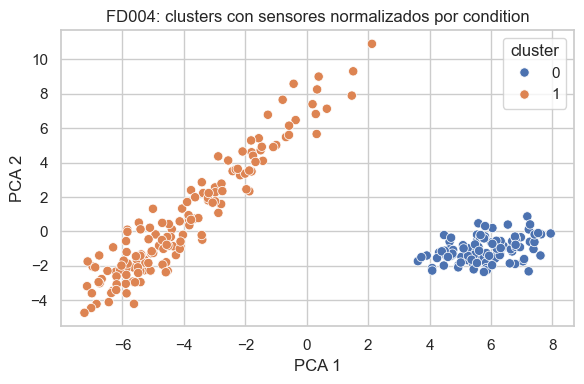

In [17]:
pca_coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
pca_plot = pd.DataFrame(pca_coords, columns=["pc1", "pc2"])
pca_plot["cluster"] = cluster.astype(str)

fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(data=pca_plot, x="pc1", y="pc2", hue="cluster", ax=ax, s=45)
ax.set_title("FD004: clusters con sensores normalizados por condition")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.legend(title="cluster")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd004_condition_normalized_fault_pattern_pca.png", dpi=150)
plt.show()


## 7. Control sin slopes y trayectorias promedio

Se repite el clustering sin slopes para evitar que la separacion dependa de la duracion total del motor. Luego se observan trayectorias promedio de sensores normalizados por condition.


In [18]:
no_slope_cols = [
    column
    for column in signature.columns
    if column.endswith("_end") or column.endswith("_delta")
]

X_no_slope = StandardScaler().fit_transform(signature[no_slope_cols])
cluster_no_slope = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=50).fit_predict(X_no_slope)
silhouette_no_slope = silhouette_score(X_no_slope, cluster_no_slope)

signature_no_slope = signature.copy()
signature_no_slope["cluster_no_slope"] = cluster_no_slope

no_slope_summary = (
    signature_no_slope.groupby("cluster_no_slope")
    .agg(
        units=("unit", "count"),
        life_cycles_mean=("life_cycles", "mean"),
    )
    .reset_index()
)
no_slope_summary["silhouette"] = silhouette_no_slope
no_slope_summary


,cluster_no_slope,units,life_cycles_mean,silhouette
0,0,101,293.7624,0.4524
1,1,148,213.3716,0.4524


In [19]:
no_slope_means = signature_no_slope.groupby("cluster_no_slope")[no_slope_cols].mean()
no_slope_top_gaps = (
    (no_slope_means.loc[1] - no_slope_means.loc[0])
    .abs()
    .sort_values(ascending=False)
    .head(12)
    .reset_index()
)
no_slope_top_gaps.columns = ["feature", "abs_gap"]
no_slope_top_gaps


,feature,abs_gap
0,sensor_12_cond_z_delta,4.8276
1,sensor_15_cond_z_end,4.8153
2,sensor_7_cond_z_delta,4.7492
3,sensor_12_cond_z_end,4.6544
4,sensor_7_cond_z_end,4.6176
5,sensor_15_cond_z_delta,4.3806
6,sensor_10_cond_z_delta,3.9853
7,sensor_21_cond_z_end,3.6924
8,sensor_20_cond_z_end,3.6841
9,sensor_10_cond_z_end,3.6638


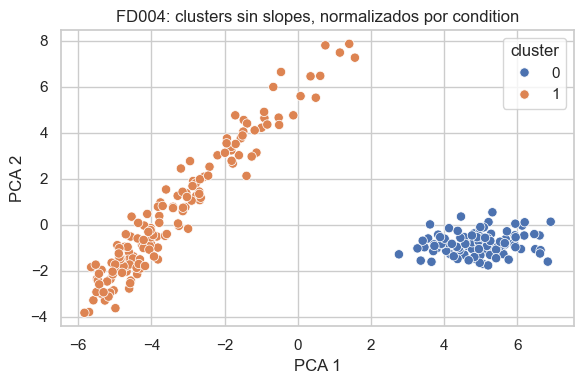

In [20]:
no_slope_pca = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_no_slope)
no_slope_pca = pd.DataFrame(no_slope_pca, columns=["pc1", "pc2"])
no_slope_pca["cluster"] = cluster_no_slope.astype(str)

fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(data=no_slope_pca, x="pc1", y="pc2", hue="cluster", ax=ax, s=45)
ax.set_title("FD004: clusters sin slopes, normalizados por condition")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.legend(title="cluster")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd004_cluster_no_slope_pca.png", dpi=150)
plt.show()


In [21]:
def base_sensor_from_feature(feature: str) -> str:
    return feature.split("_cond_z")[0]

key_sensors = []
for feature in no_slope_top_gaps["feature"]:
    sensor = base_sensor_from_feature(feature)
    if sensor not in key_sensors:
        key_sensors.append(sensor)
    if len(key_sensors) == 3:
        break

clustered_train = train_cond_norm.merge(
    signature_no_slope[["unit", "cluster_no_slope"]],
    on="unit",
    how="left",
)
clustered_train["max_cycle"] = clustered_train.groupby("unit")["cycle"].transform("max")
clustered_train["life_pct"] = clustered_train["cycle"] / clustered_train["max_cycle"]
clustered_train["life_bin"] = pd.cut(
    clustered_train["life_pct"],
    bins=np.linspace(0, 1, 21),
    include_lowest=True,
    labels=False,
)
clustered_train["life_bin_mid"] = (clustered_train["life_bin"] + 0.5) / 20

key_sensor_cols = [f"{sensor}_cond_z" for sensor in key_sensors]
cluster_trajectories = (
    clustered_train.groupby(["cluster_no_slope", "life_bin_mid"], as_index=False)[key_sensor_cols]
    .mean()
)
key_sensors


['sensor_12', 'sensor_15', 'sensor_7']

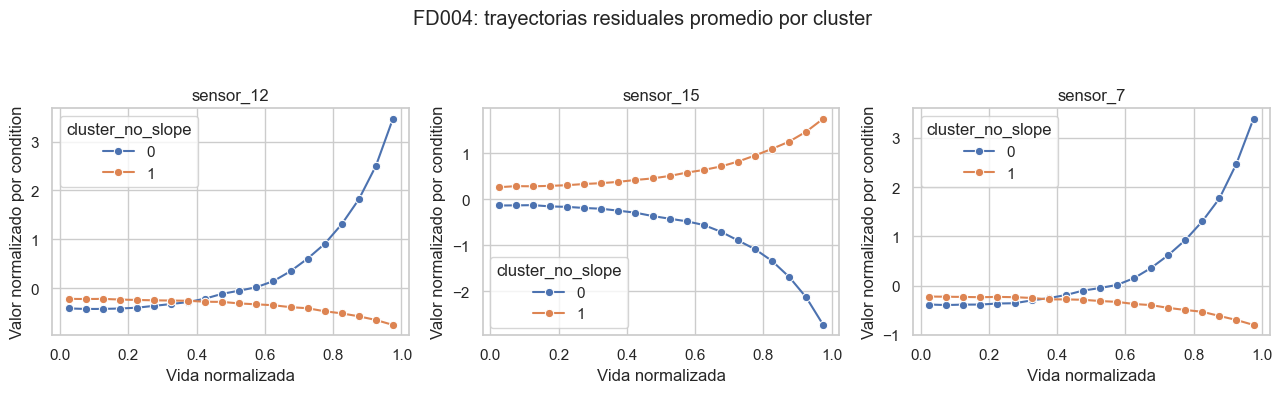

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True)
for ax, sensor, sensor_col in zip(axes, key_sensors, key_sensor_cols):
    sns.lineplot(
        data=cluster_trajectories,
        x="life_bin_mid",
        y=sensor_col,
        hue="cluster_no_slope",
        marker="o",
        ax=ax,
    )
    ax.set_title(sensor)
    ax.set_xlabel("Vida normalizada")
    ax.set_ylabel("Valor normalizado por condition")

fig.suptitle("FD004: trayectorias residuales promedio por cluster", y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig(FIGURES_DIR / "fd004_cluster_sensor_trajectories.png", dpi=150)
plt.show()


## 8. Lectura final

- FD004 confirma la parte de conditions: los settings recuperan seis regimes operativos claros. En la muestra usada para validar `k`, el silhouette de `k=6` es aproximadamente 0.997.
- Cada motor de train recorre las seis conditions, igual que en FD002. La condition cambia dentro de la trayectoria, no define un motor completo.
- Train y test tienen proporciones parecidas por condition a nivel fila. La condition 6 aparece mas que las demas, cerca de 25%; las otras quedan alrededor de 15%.
- Como en FD002, la correlacion global sensor-RUL subestima la senal porque mezcla regimes. Al normalizar por condition, sensores como `sensor_11`, `sensor_4`, `sensor_17`, `sensor_3`, `sensor_2` y `sensor_9` vuelven a ser informativos.
- Despues de normalizar por condition, aparecen dos clusters residuales de motores. Con slopes, el silhouette es aproximadamente 0.423; sin slopes, sube a aproximadamente 0.452.
- Los clusters residuales difieren tambien en vida media: aproximadamente 294 ciclos contra 213 ciclos. Esto puede ser compatible con patrones de falla distintos, pero tambien puede capturar diferencias de duracion/degradacion.
- Las trayectorias residuales muestran dinamicas distintas en `sensor_12`, `sensor_15` y `sensor_7`, lo que refuerza que los clusters no son solo una separacion geometrica.
- La interpretacion es mas debil que en FD003 porque FD004 mezcla dos fuentes de complejidad: conditions y fault modes. No se puede afirmar que cada cluster sea un fault mode real.
- Para modelado FD004, un baseline serio debe controlar conditions. Como extension, se pueden analizar errores por cluster residual para ver si el modelo falla distinto en cada patron.
